<a href="https://colab.research.google.com/github/Subhajit14mandal/sentiment-analysis-simple-rnn/blob/main/Sentiment_Analysis_Using_Simple_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir ~/.kaggle/
!cp "/content/drive/MyDrive/RNN/kaggle.json" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
mkdir: cannot create directory ‘/root/.kaggle/’: File exists


In [ ]:
!kaggle datasets download -d mdismielhossenabir/sentiment-analysis -p "/content/drive/MyDrive/RNN"
!unzip "/content/drive/MyDrive/RNN/sentiment-analysis.zip" -d "/content/drive/MyDrive/RNN"
!rm "/content/drive/MyDrive/RNN/sentiment-analysis.zip"

Dataset URL: https://www.kaggle.com/datasets/mdismielhossenabir/sentiment-analysis
License(s): MIT
  0% 0.00/14.3k [00:00<?, ?B/s]
100% 14.3k/14.3k [00:00<00:00, 667kB/s]
Archive:  /content/drive/MyDrive/RNN/sentiment-analysis.zip
  inflating: /content/drive/MyDrive/RNN/sentiment_analysis.csv  



# Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dense,Dropout,SimpleRNN,Input

In [5]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Import Dataset

In [6]:
df = pd.read_csv('/content/drive/MyDrive/RNN/sentiment_analysis.csv')
df.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram


# Data Preprocessing

In [7]:
df.isnull().sum()

,0
Year,0
Month,0
Day,0
Time of Tweet,0
text,0
sentiment,0
Platform,0


In [8]:
df['sentiment'].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [9]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sentiment']=le.fit_transform(df['sentiment'])

In [10]:
df.head()

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,2,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",2,Facebook
2,2017,8,18,night,Don't angry me,0,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,0,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",0,Instagram


In [11]:
df['sentiment'].unique()

array([2, 0, 1])

In [12]:
text=df['text']
label=df['sentiment']

In [13]:
label.unique()

array([2, 0, 1])

In [14]:
label.isnull().sum()

np.int64(0)

In [15]:
label.value_counts()

,count
sentiment,
1,199
2,166
0,134


 ## Tokenization

In [16]:
token = Tokenizer(oov_token='<oov>')
token.fit_on_texts(text)

In [17]:
token.word_index

{'<oov>': 1,
 'i': 2,
 'to': 3,
 'the': 4,
 'you': 5,
 'a': 6,
 'and': 7,
 'my': 8,
 'it': 9,
 'for': 10,
 'is': 11,
 'in': 12,
 'that': 13,
 'me': 14,
 's': 15,
 'm': 16,
 'day': 17,
 'are': 18,
 'have': 19,
 'of': 20,
 'but': 21,
 'on': 22,
 't': 23,
 'was': 24,
 'just': 25,
 'now': 26,
 'love': 27,
 'so': 28,
 'be': 29,
 'with': 30,
 'not': 31,
 'know': 32,
 'what': 33,
 'like': 34,
 'going': 35,
 'we': 36,
 'go': 37,
 'up': 38,
 'this': 39,
 'happy': 40,
 'all': 41,
 'today': 42,
 'really': 43,
 'do': 44,
 'out': 45,
 'back': 46,
 'at': 47,
 'am': 48,
 'its': 49,
 'good': 50,
 'got': 51,
 'im': 52,
 'want': 53,
 'can': 54,
 'too': 55,
 'there': 56,
 'will': 57,
 'tomorrow': 58,
 'no': 59,
 'amazing': 60,
 'home': 61,
 'from': 62,
 'new': 63,
 'miss': 64,
 '2': 65,
 'time': 66,
 "i'm": 67,
 'if': 68,
 'morning': 69,
 'some': 70,
 'get': 71,
 'sorry': 72,
 'her': 73,
 'about': 74,
 'need': 75,
 'one': 76,
 'don': 77,
 'night': 78,
 'when': 79,
 'much': 80,
 'only': 81,
 'your': 82,
 

In [18]:
token.document_count

499

In [19]:
seq=token.texts_to_sequences(texts=text)

## Padding

In [20]:
pad=pad_sequences(seq,padding='post',truncating='post')

In [21]:
pad

array([[  33,    6,   98, ...,    0,    0,    0],
       [   2,   84,   72, ...,    0,    0,    0],
       [ 126,  405,   14, ...,    0,    0,    0],
       ...,
       [1431,   41,    8, ...,    0,    0,    0],
       [1434,    5, 1435, ...,    0,    0,    0],
       [ 204,    2,  395, ...,    0,    0,    0]], dtype=int32)

In [22]:
x=pad
y=label

## Train-Test Splitting

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,
                                               test_size=0.2,
                                               stratify=y,
                                               random_state=42)

In [24]:
y_test.value_counts()

,count
sentiment,
1,40
2,33
0,27


In [25]:
y_train.value_counts()

,count
sentiment,
1,159
2,133
0,107


In [26]:
x_train.shape

(399, 31)

In [27]:
y_train[:10]

,sentiment
263,1
62,1
163,0
437,0
480,0
24,1
86,1
445,1
272,1
399,0


In [28]:
y_train.unique()

array([1, 0, 2])

In [29]:
vocab_size = len(token.word_index) + 1
max_len = x_train.shape[1]
vocab_size,max_len

(1439, 31)

# RNN Model

## Built Model

In [30]:
model=Sequential()
model.add(Input(shape=(max_len,)))
model.add(Embedding(input_dim=vocab_size,
                    output_dim=64,
                    input_length=max_len))
model.add(SimpleRNN(128,return_sequences=True))
model.add(SimpleRNN(64))
model.add(Dense(32,activation='relu'))
model.add(Dense(3,activation='softmax'))
# model.build(input_shape=(None, x_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Model Compilation

In [31]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 31, 64)         │        92,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 31, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,331 (513.01 KB)

 Trainable params: 131,331 (513.01 KB)

 Non-trainable params: 0 (0.00 B)

## Early Stopping

In [33]:

from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

## Train Model

In [34]:
model.fit(x_train,y_train,epochs=100,
          validation_split=0.2,
          callbacks=[early_stop])

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.4326 - loss: 1.0787 - val_accuracy: 0.3875 - val_loss: 1.0992
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7429 - loss: 0.7438 - val_accuracy: 0.4125 - val_loss: 1.1712
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8966 - loss: 0.3460 - val_accuracy: 0.4750 - val_loss: 1.3237
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9749 - loss: 0.1229 - val_accuracy: 0.5125 - val_loss: 1.4610


# Evolution

In [35]:
loss,acc=model.evaluate(x_test,y_test)
loss,acc

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3500 - loss: 1.0476


(1.0476319789886475, 0.3499999940395355)

## Classification Report & Confution Matrix

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
              precision    recall  f1-score   support

           0       0.20      0.04      0.06        27
           1       0.40      0.25      0.31        40
           2       0.34      0.73      0.47        33

    accuracy                           0.35       100
   macro avg       0.31      0.34      0.28       100
weighted avg       0.33      0.35      0.29       100



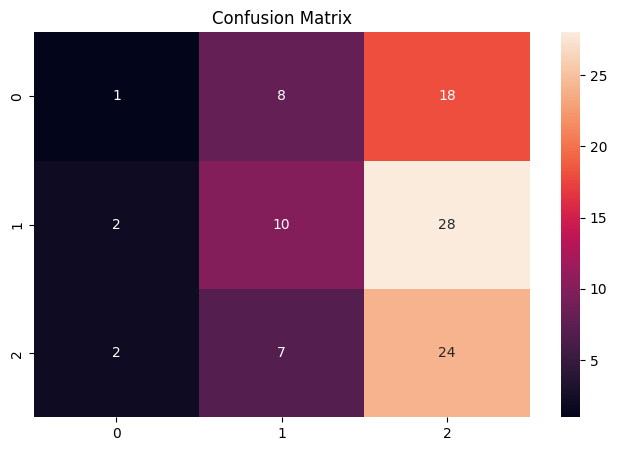

<Figure size 640x480 with 0 Axes>

In [43]:
y_pred=model.predict(x_test)
y_pred=np.argmax(y_pred,axis=1)
print(classification_report(y_test,y_pred, zero_division=1))




plt.figure(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.show()

## Accuracy Plotting

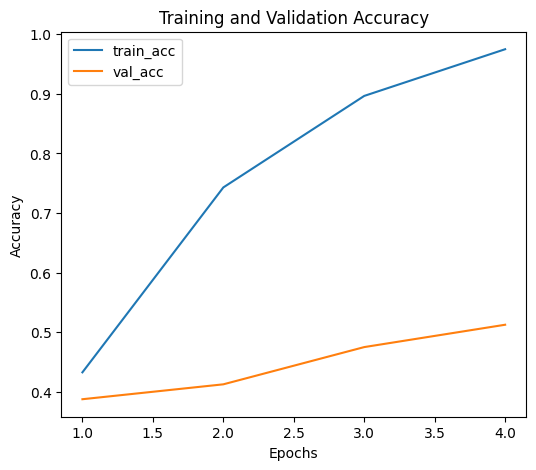

In [37]:
train_acc=model.history.history['accuracy']
val_acc=model.history.history['val_accuracy']

num_epochs = len(train_acc)

plt.figure(figsize=(6,5))
plt.plot(range(1,num_epochs+1),train_acc,label='train_acc')
plt.plot(range(1,num_epochs+1),val_acc,label='val_acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()